# Early Exit — SimCLR Backbone
Follows the solution structure: 3 exits (after layer2, layer3, layer4).
Backbone weights from SimCLR pretraining. layer2/3/4 fine-tuned jointly with exit heads.

In [1]:
import os, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


### Load Data

In [2]:
train_dir = Path('dataset_ood/train')
val_dir   = Path('dataset_ood/val')
test_dir  = Path('dataset_ood/test')

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = ImageFolder(train_dir, transform=train_tfms)
val_ds   = ImageFolder(val_dir,   transform=val_tfms)
test_ds  = ImageFolder(test_dir,  transform=val_tfms)

num_workers = 0 if DEVICE.type == 'mps' else 2
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=num_workers)

num_classes = len(train_ds.classes)
print('Classes:', train_ds.classes)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Classes: ['CORROSION', 'NOCORROSION']
Train: 2522 | Val: 653 | Test: 182


### Model Implementation

In [3]:
import torch.nn.functional as F

# --- Load SimCLR checkpoint and reconstruct backbone ---
class SimCLR(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        base = models.resnet18(weights=None)
        self.encoder   = nn.Sequential(*list(base.children())[:-1])
        self.feat_dim  = base.fc.in_features
        self.projector = nn.Sequential(
            nn.Linear(self.feat_dim, self.feat_dim),
            nn.ReLU(),
            nn.Linear(self.feat_dim, proj_dim),
        )
    def forward(self, x):
        h = self.encoder(x).squeeze(-1).squeeze(-1)
        z = self.projector(h)
        return h, F.normalize(z, dim=1)

simclr = SimCLR(proj_dim=128)
simclr.load_state_dict(torch.load('simclr_best.pt', map_location='cpu'))
simclr.eval()

# Map SimCLR encoder Sequential → named ResNet18 backbone attributes
enc = list(simclr.encoder.children())
backbone = models.resnet18(weights=None)
backbone.conv1   = enc[0]
backbone.bn1     = enc[1]
backbone.relu    = enc[2]
backbone.maxpool = enc[3]
backbone.layer1  = enc[4]
backbone.layer2  = enc[5]
backbone.layer3  = enc[6]
backbone.layer4  = enc[7]
backbone.avgpool = enc[8]
backbone.fc      = nn.Identity()
backbone = backbone.to(DEVICE)

# Exit heads
exit1_head = nn.Sequential(
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(128, num_classes),
).to(DEVICE)

exit2_head = nn.Sequential(
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(256, num_classes),
).to(DEVICE)

final_head = nn.Linear(512, num_classes).to(DEVICE)

# Freeze all, then unfreeze layer2/3/4
for p in backbone.parameters():
    p.requires_grad = False
for layer in [backbone.layer2, backbone.layer3, backbone.layer4]:
    for p in layer.parameters():
        p.requires_grad = True

def forward_early_exit(x):
    x = backbone.conv1(x)
    x = backbone.bn1(x)
    x = backbone.relu(x)
    x = backbone.maxpool(x)
    x = backbone.layer1(x)
    x = backbone.layer2(x);  exit1_logits = exit1_head(x)
    x = backbone.layer3(x);  exit2_logits = exit2_head(x)
    x = backbone.layer4(x)
    x = backbone.avgpool(x)
    x = torch.flatten(x, 1)
    final_logits = final_head(x)
    return exit1_logits, exit2_logits, final_logits

trainable = sum(p.numel() for p in list(backbone.parameters()) +
               list(exit1_head.parameters()) + list(exit2_head.parameters()) +
               list(final_head.parameters()) if p.requires_grad)
print(f'Trainable params: {trainable:,}')

Trainable params: 11,020,806


### Training Function

In [4]:
def train_model(criterion, optimizer, num_epochs=15, best_path='early_exit_simclr.pt'):
    history = {
        'train_loss': [], 'val_loss': [],
        'train_exit1_acc': [], 'train_exit2_acc': [], 'train_final_acc': [],
        'val_exit1_acc':   [], 'val_exit2_acc':   [], 'val_final_acc':   [],
    }
    best_val_final_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                backbone.train(); exit1_head.train(); exit2_head.train(); final_head.train()
                loader = train_loader
            else:
                backbone.eval();  exit1_head.eval();  exit2_head.eval();  final_head.eval()
                loader = val_loader

            running_loss = 0.0
            correct_exit1 = correct_exit2 = correct_final = total = 0

            for inputs, labels in loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    e1, e2, ef = forward_early_exit(inputs)
                    loss = 0.2 * criterion(e1, labels) + 0.3 * criterion(e2, labels) + 1.0 * criterion(ef, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss   += loss.item() * inputs.size(0)
                correct_exit1  += (e1.argmax(1) == labels).sum().item()
                correct_exit2  += (e2.argmax(1) == labels).sum().item()
                correct_final  += (ef.argmax(1) == labels).sum().item()
                total          += labels.size(0)

            n = total
            history[f'{phase}_loss'].append(running_loss / n)
            history[f'{phase}_exit1_acc'].append(correct_exit1 / n)
            history[f'{phase}_exit2_acc'].append(correct_exit2 / n)
            history[f'{phase}_final_acc'].append(correct_final / n)
            print(f'{phase:5s} | loss={running_loss/n:.4f} | exit1={correct_exit1/n:.4f} | exit2={correct_exit2/n:.4f} | final={correct_final/n:.4f}')

            if phase == 'val' and correct_final / n > best_val_final_acc:
                best_val_final_acc = correct_final / n
                torch.save({
                    'backbone':   backbone.state_dict(),
                    'exit1_head': exit1_head.state_dict(),
                    'exit2_head': exit2_head.state_dict(),
                    'final_head': final_head.state_dict(),
                    'class_names': train_ds.classes,
                }, best_path)
        print()

    print('Best val final acc:', best_val_final_acc)
    return history

### Loss / Optimizer

In [5]:
criterion = nn.CrossEntropyLoss()

trainable_params = (
    list(backbone.layer2.parameters()) +
    list(backbone.layer3.parameters()) +
    list(backbone.layer4.parameters()) +
    list(exit1_head.parameters()) +
    list(exit2_head.parameters()) +
    list(final_head.parameters())
)

optimizer = optim.Adam(trainable_params, lr=1e-4, weight_decay=1e-4)

### Train

In [6]:
history = train_model(criterion=criterion, optimizer=optimizer, num_epochs=15, best_path='early_exit_simclr.pt')

Epoch 1/15
----------
train | loss=0.6394 | exit1=0.5789 | exit2=0.6051 | final=0.8648
val   | loss=0.6977 | exit1=0.6493 | exit2=0.7289 | final=0.8515

Epoch 2/15
----------
train | loss=0.4740 | exit1=0.5944 | exit2=0.7070 | final=0.9405
val   | loss=0.7857 | exit1=0.6983 | exit2=0.7458 | final=0.8331

Epoch 3/15
----------
train | loss=0.4181 | exit1=0.6495 | exit2=0.7839 | final=0.9540
val   | loss=0.6942 | exit1=0.7090 | exit2=0.7642 | final=0.8622

Epoch 4/15
----------
train | loss=0.3641 | exit1=0.6784 | exit2=0.8057 | final=0.9730
val   | loss=0.6937 | exit1=0.7228 | exit2=0.7596 | final=0.8698

Epoch 5/15
----------
train | loss=0.3365 | exit1=0.7034 | exit2=0.8259 | final=0.9746
val   | loss=0.7140 | exit1=0.7274 | exit2=0.7749 | final=0.8668

Epoch 6/15
----------
train | loss=0.3158 | exit1=0.7169 | exit2=0.8398 | final=0.9758
val   | loss=0.7800 | exit1=0.7351 | exit2=0.7657 | final=0.8683

Epoch 7/15
----------
train | loss=0.2905 | exit1=0.7363 | exit2=0.8529 | final=0.

### Training History Plots

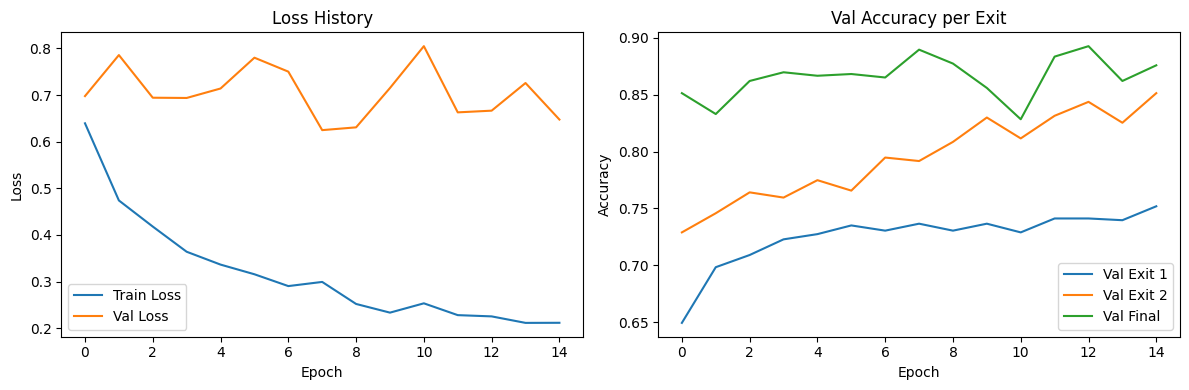

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(history['val_exit1_acc'], label='Val Exit 1')
plt.plot(history['val_exit2_acc'], label='Val Exit 2')
plt.plot(history['val_final_acc'], label='Val Final')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Val Accuracy per Exit')

plt.tight_layout(); plt.savefig('simclr_ee_history.png', dpi=150); plt.show()

### Multi-Exit Routing

In [8]:
# Load best checkpoint
ckpt = torch.load('early_exit_simclr.pt', map_location=DEVICE)
backbone.load_state_dict(ckpt['backbone'])
exit1_head.load_state_dict(ckpt['exit1_head'])
exit2_head.load_state_dict(ckpt['exit2_head'])
final_head.load_state_dict(ckpt['final_head'])

def evaluate_routed_inference(dataloader, tau1=0.90, tau2=0.90):
    backbone.eval(); exit1_head.eval(); exit2_head.eval(); final_head.eval()
    total = correct = exit1_count = exit2_count = final_count = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            e1, e2, ef = forward_early_exit(inputs)

            p1 = torch.softmax(e1, 1); c1, pred1 = p1.max(1)
            p2 = torch.softmax(e2, 1); c2, pred2 = p2.max(1)
            predf = ef.argmax(1)

            batch_preds = []
            for i in range(labels.size(0)):
                if   c1[i] >= tau1: pred = pred1[i]; exit1_count += 1
                elif c2[i] >= tau2: pred = pred2[i]; exit2_count += 1
                else:               pred = predf[i]; final_count += 1
                batch_preds.append(pred.item())

            batch_preds = torch.tensor(batch_preds, device=labels.device)
            correct += (batch_preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(batch_preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    print(f'Accuracy: {acc:.4f} | Exit1: {exit1_count/total:.4f} | Exit2: {exit2_count/total:.4f} | Final: {final_count/total:.4f}')
    return acc, exit1_count/total, exit2_count/total, final_count/total, all_preds, all_labels

routed_acc, r1, r2, rf, routed_preds, routed_labels = evaluate_routed_inference(test_loader, tau1=0.90, tau2=0.90)

Accuracy: 0.9560 | Exit1: 0.0000 | Exit2: 0.4670 | Final: 0.5330


### Threshold Sweep

In [9]:
thresholds = [0.70, 0.80, 0.85, 0.90, 0.95]
simclr_results = []

for tau in thresholds:
    acc, r1, r2, rf, _, _ = evaluate_routed_inference(test_loader, tau1=tau, tau2=tau)
    simclr_results.append((tau, acc, r1, r2, rf))
    print()

Accuracy: 0.9505 | Exit1: 0.4011 | Exit2: 0.4066 | Final: 0.1923

Accuracy: 0.9615 | Exit1: 0.1154 | Exit2: 0.5055 | Final: 0.3791

Accuracy: 0.9560 | Exit1: 0.0055 | Exit2: 0.5604 | Final: 0.4341

Accuracy: 0.9560 | Exit1: 0.0000 | Exit2: 0.4670 | Final: 0.5330

Accuracy: 0.9560 | Exit1: 0.0000 | Exit2: 0.2747 | Final: 0.7253



### Confusion Matrices

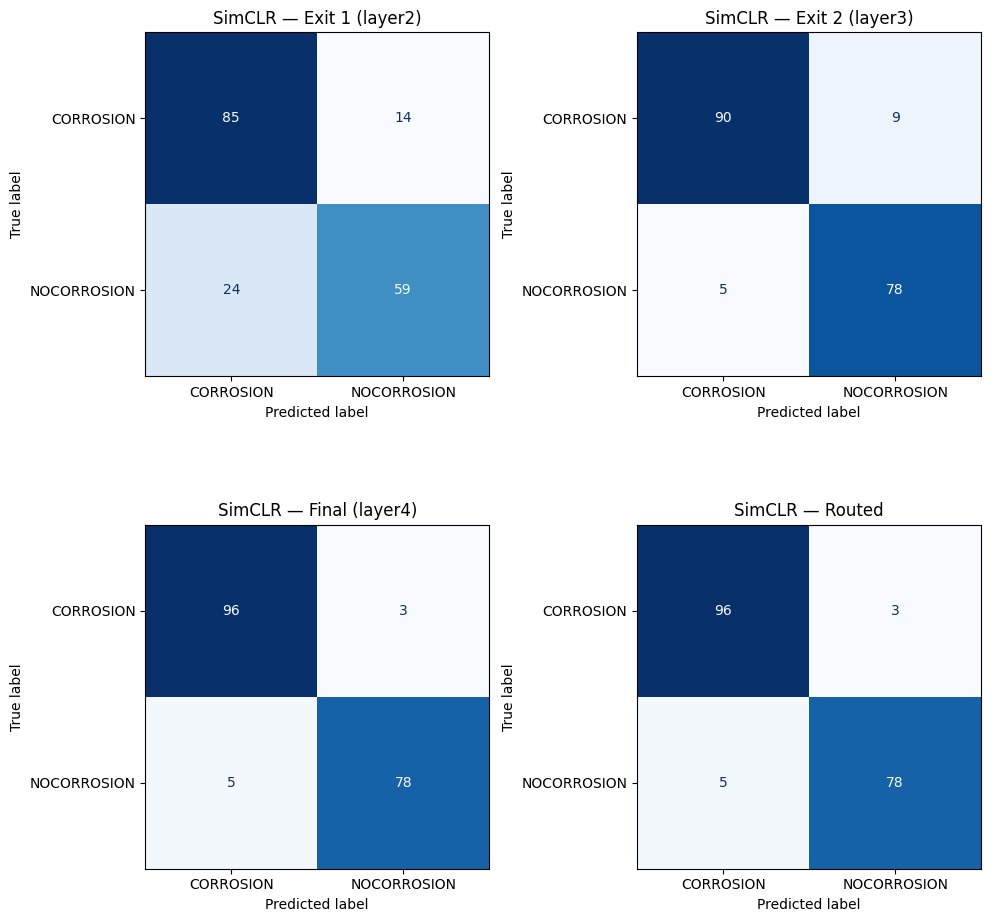

In [10]:
def get_all_exit_predictions(dataloader, tau1=0.90, tau2=0.90):
    backbone.eval(); exit1_head.eval(); exit2_head.eval(); final_head.eval()
    y_true, y_exit1, y_exit2, y_final, y_routed = [], [], [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            e1, e2, ef = forward_early_exit(inputs)
            p1 = torch.softmax(e1, 1); c1, pred1 = p1.max(1)
            p2 = torch.softmax(e2, 1); c2, pred2 = p2.max(1)
            predf = ef.argmax(1)

            routed = []
            for i in range(labels.size(0)):
                if   c1[i] >= tau1: routed.append(pred1[i].item())
                elif c2[i] >= tau2: routed.append(pred2[i].item())
                else:               routed.append(predf[i].item())

            y_true.extend(labels.cpu().numpy())
            y_exit1.extend(pred1.cpu().numpy())
            y_exit2.extend(pred2.cpu().numpy())
            y_final.extend(predf.cpu().numpy())
            y_routed.extend(routed)

    return y_true, y_exit1, y_exit2, y_final, y_routed

y_true, y_exit1, y_exit2, y_final, y_routed = get_all_exit_predictions(test_loader, tau1=0.90, tau2=0.90)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for (title, preds, ax) in [
    ('Exit 1 (layer2)', y_exit1, axes[0,0]),
    ('Exit 2 (layer3)', y_exit2, axes[0,1]),
    ('Final (layer4)',  y_final, axes[1,0]),
    ('Routed',          y_routed, axes[1,1]),
]:
    cm = confusion_matrix(y_true, preds)
    ConfusionMatrixDisplay(cm, display_labels=train_ds.classes).plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f'SimCLR — {title}')
plt.tight_layout(); plt.savefig('simclr_ee_confusion.png', dpi=150); plt.show()

### Exit Rates and Accuracy vs Threshold

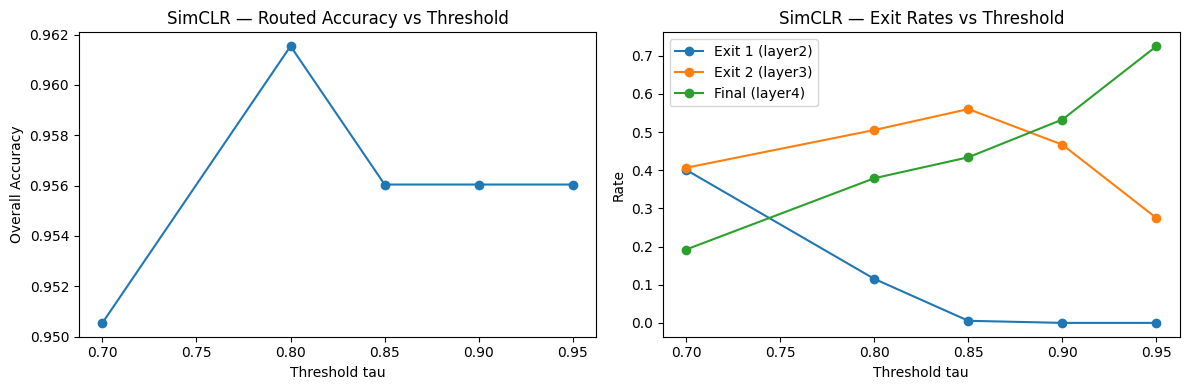

Results saved to simclr_ee_results.json


In [11]:
taus       = [x[0] for x in simclr_results]
accs       = [x[1] for x in simclr_results]
exit1_rates = [x[2] for x in simclr_results]
exit2_rates = [x[3] for x in simclr_results]
final_rates = [x[4] for x in simclr_results]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(taus, accs, marker='o'); plt.xlabel('Threshold tau'); plt.ylabel('Overall Accuracy')
plt.title('SimCLR — Routed Accuracy vs Threshold')

plt.subplot(1, 2, 2)
plt.plot(taus, exit1_rates, marker='o', label='Exit 1 (layer2)')
plt.plot(taus, exit2_rates, marker='o', label='Exit 2 (layer3)')
plt.plot(taus, final_rates, marker='o', label='Final (layer4)')
plt.xlabel('Threshold tau'); plt.ylabel('Rate'); plt.legend()
plt.title('SimCLR — Exit Rates vs Threshold')
plt.tight_layout(); plt.savefig('simclr_ee_rates.png', dpi=150); plt.show()

# Save results for comparison notebook
import json
with open('simclr_ee_results.json', 'w') as f:
    json.dump(simclr_results, f)
print('Results saved to simclr_ee_results.json')

---
# Section 2 — Supervised Early Exit

# Early Exit — Supervised Backbone
3 exits (after layer2, layer3, layer4).
Backbone weights from supervised full fine-tuning. layer2/3/4 further fine-tuned jointly with exit heads.

In [51]:
import os
from pathlib import Path
from copy import deepcopy

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


### Load Data

In [52]:
train_dir = Path('dataset_ood/train')
val_dir   = Path('dataset_ood/val')
test_dir  = Path('dataset_ood/test')

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = ImageFolder(train_dir, transform=train_tfms)
val_ds   = ImageFolder(val_dir,   transform=val_tfms)
test_ds  = ImageFolder(test_dir,  transform=val_tfms)

num_workers = 0 if DEVICE.type == 'mps' else 2
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=num_workers)

num_classes = len(train_ds.classes)
print('Classes:', train_ds.classes)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Classes: ['CORROSION', 'NOCORROSION']
Train: 2522 | Val: 653 | Test: 182


### Model Implementation

In [ ]:
class EarlyExitSupervised(nn.Module):
    def __init__(self, num_classes, checkpoint_path=None, device="cpu"):
        super().__init__()

        self.device = device

        self.quant_exit1 = tq.QuantStub()
        self.dequant_exit1 = tq.DeQuantStub()

        self.quant_exit2 = tq.QuantStub()
        self.dequant_exit2 = tq.DeQuantStub()



        # Load supervised checkpoint and strip fc head
        sup_full = models.resnet18(weights=None)
        sup_full.fc = nn.Linear(512, num_classes)
        sup_full.load_state_dict(torch.load('sup_best.pt', map_location='cpu'))

        backbone = sup_full
        backbone.fc = nn.Identity()
        self.backbone = backbone

        # Exit heads
        self.exit1_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, num_classes),
        )

        self.exit2_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, num_classes),
        )

        self.final_head = nn.Linear(512, num_classes)

        # Freeze all, then unfreeze layer2/3/4
        for p in self.backbone.parameters():
            p.requires_grad = False
        for layer in [self.backbone.layer2, self.backbone.layer3, self.backbone.layer4]:
            for p in layer.parameters():
                p.requires_grad = True

        self.to(device)

    def forward_early_exit(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x);  exit1_logits = self.exit1_head(x)
        x = self.backbone.layer3(x);  exit2_logits = self.exit2_head(x)
        x = self.backbone.layer4(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        final_logits = self.final_head(x)
        return exit1_logits, exit2_logits, final_logits
        
    def count_trainable_params(self):
            return sum(p.numel() for p in self.parameters() if p.requires_grad)

#trainable = sum(p.numel() for p in list(backbone.parameters()) +
#               list(exit1_head.parameters()) + list(exit2_head.parameters()) +
#               list(final_head.parameters()) if p.requires_grad)
#print(f'Trainable params: {trainable:,}')

model = EarlyExitSupervised(num_classes=num_classes,
                            checkpoint_path=None,
                            device=DEVICE)

trainable = model.count_trainable_params()
print(f"Trainable params: {trainable:,}")



Trainable params: 11,020,806


### Training Function

In [54]:
def train_model(model, criterion, optimizer, train_loader, val_loader,
                num_epochs=15, best_path='early_exit_supervised.pt'):

    history = {
        'train_loss': [], 'val_loss': [],
        'train_exit1_acc': [], 'train_exit2_acc': [], 'train_final_acc': [],
        'val_exit1_acc':   [], 'val_exit2_acc':   [], 'val_final_acc':   [],
    }

    best_val_final_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                loader = train_loader
            else:
                model.eval()
                loader = val_loader

            running_loss = 0.0
            correct_exit1 = correct_exit2 = correct_final = total = 0

            for inputs, labels in loader:
                inputs = inputs.to(model.device)
                labels = labels.to(model.device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    e1, e2, ef = model.forward_early_exit(inputs)

                    loss = (
                        0.2 * criterion(e1, labels) +
                        0.3 * criterion(e2, labels) +
                        1.0 * criterion(ef, labels)
                    )

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)

                correct_exit1 += (e1.argmax(1) == labels).sum().item()
                correct_exit2 += (e2.argmax(1) == labels).sum().item()
                correct_final += (ef.argmax(1) == labels).sum().item()
                total += labels.size(0)

            n = total
            epoch_loss = running_loss / n
            exit1_acc = correct_exit1 / n
            exit2_acc = correct_exit2 / n
            final_acc = correct_final / n

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_exit1_acc'].append(exit1_acc)
            history[f'{phase}_exit2_acc'].append(exit2_acc)
            history[f'{phase}_final_acc'].append(final_acc)

            print(f'{phase:5s} | loss={epoch_loss:.4f} | '
                  f'exit1={exit1_acc:.4f} | exit2={exit2_acc:.4f} | final={final_acc:.4f}')

            # ---- Save best model ----
            if phase == 'val' and final_acc > best_val_final_acc:
                best_val_final_acc = final_acc
                torch.save({
                    'model_state_dict': model.state_dict(),
                    'class_names': getattr(train_loader.dataset, 'classes', None),
                }, best_path)

        print()

    print('Best val final acc:', best_val_final_acc)
    return history

### Loss / Optimizer

In [55]:
criterion = nn.CrossEntropyLoss()

trainable_params = filter(lambda p: p.requires_grad, model.parameters())

optimizer = optim.Adam(trainable_params, lr=1e-4, weight_decay=1e-4)

### Train

In [56]:
history = train_model(model=model, criterion=criterion, optimizer=optimizer, train_loader=train_loader, val_loader=val_loader, num_epochs=15, best_path='early_exit_supervised.pt')

Epoch 1/15
----------
train | loss=0.4465 | exit1=0.6063 | exit2=0.6427 | final=0.9592
val   | loss=0.6491 | exit1=0.7167 | exit2=0.7473 | final=0.8867

Epoch 2/15
----------
train | loss=0.3773 | exit1=0.6471 | exit2=0.7859 | final=0.9762
val   | loss=0.6266 | exit1=0.6876 | exit2=0.7626 | final=0.8836

Epoch 3/15
----------
train | loss=0.3595 | exit1=0.6312 | exit2=0.8426 | final=0.9742
val   | loss=0.6221 | exit1=0.7044 | exit2=0.7795 | final=0.9051

Epoch 4/15
----------
train | loss=0.3283 | exit1=0.6618 | exit2=0.8596 | final=0.9818
val   | loss=0.6420 | exit1=0.7366 | exit2=0.7979 | final=0.9051

Epoch 5/15
----------
train | loss=0.3084 | exit1=0.6907 | exit2=0.8604 | final=0.9822
val   | loss=0.6041 | exit1=0.7443 | exit2=0.8147 | final=0.9051

Epoch 6/15
----------
train | loss=0.3146 | exit1=0.7268 | exit2=0.8838 | final=0.9758
val   | loss=0.9274 | exit1=0.7473 | exit2=0.8178 | final=0.8392

Epoch 7/15
----------
train | loss=0.2846 | exit1=0.7466 | exit2=0.8826 | final=0.

### Training History Plots

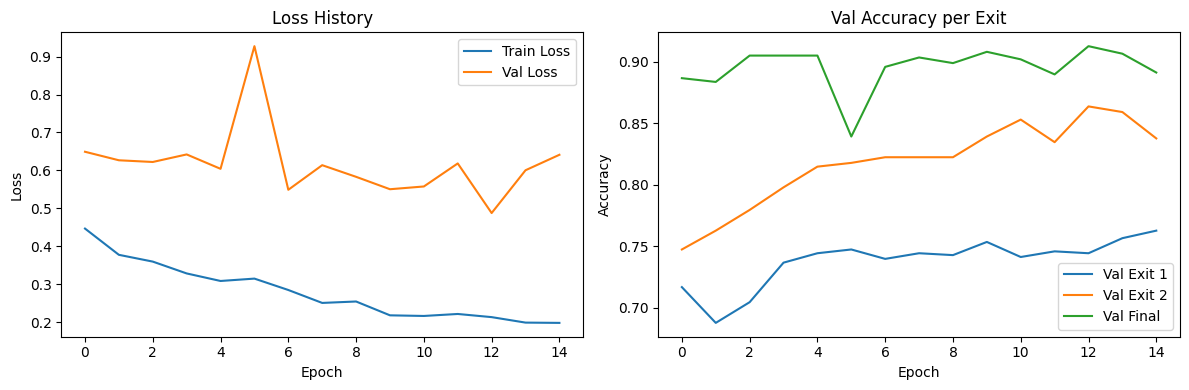

In [57]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(history['val_exit1_acc'], label='Val Exit 1')
plt.plot(history['val_exit2_acc'], label='Val Exit 2')
plt.plot(history['val_final_acc'], label='Val Final')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Val Accuracy per Exit')

plt.tight_layout(); plt.savefig('sup_ee_history.png', dpi=150); plt.show()

### Multi-Exit Routing

In [ ]:
ckpt = torch.load('early_exit_supervised.pt', map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.to(DEVICE)

def evaluate_routed_inference(model, dataloader, tau1=0.90, tau2=0.90):
    model.eval()

    total = 0
    correct = 0
    exit1_count = 0
    exit2_count = 0
    final_count = 0

    all_preds, all_labels = [], []

    device = next(model.parameters()).device

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            e1, e2, ef = model.forward_early_exit(inputs)

            p1 = torch.softmax(e1, dim=1)
            c1, pred1 = p1.max(dim=1)

            p2 = torch.softmax(e2, dim=1)
            c2, pred2 = p2.max(dim=1)

            predf = ef.argmax(dim=1)

            batch_preds = []

            for i in range(labels.size(0)):
                if c1[i] >= tau1:
                    pred = pred1[i]
                    exit1_count += 1
                elif c2[i] >= tau2:
                    pred = pred2[i]
                    exit2_count += 1
                else:
                    pred = predf[i]
                    final_count += 1

                batch_preds.append(pred.item())

            batch_preds = torch.tensor(batch_preds, device=device)

            correct += (batch_preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(batch_preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total

    print(
        f'Accuracy: {acc:.4f} | '
        f'Exit1: {exit1_count/total:.4f} | '
        f'Exit2: {exit2_count/total:.4f} | '
        f'Final: {final_count/total:.4f}'
    )

    return acc, exit1_count/total, exit2_count/total, final_count/total, all_preds, all_labels
routed_acc, r1, r2, rf, routed_preds, routed_labels = evaluate_routed_inference(model, test_loader, tau1=0.90, tau2=0.90)


Accuracy: 0.9451 | Exit1: 0.0000 | Exit2: 0.4396 | Final: 0.5604


### Threshold Sweep

In [20]:
thresholds = [0.70, 0.80, 0.85, 0.90, 0.95]
sup_results = []

for tau in thresholds:
    acc, r1, r2, rf, routed_preds, routed_labels = evaluate_routed_inference(model, test_loader, tau1=tau, tau2=tau)
    sup_results.append((tau, acc, r1, r2, rf))
    print()

Accuracy: 0.9396 | Exit1: 0.3462 | Exit2: 0.4505 | Final: 0.2033

Accuracy: 0.9451 | Exit1: 0.0714 | Exit2: 0.5934 | Final: 0.3352

Accuracy: 0.9451 | Exit1: 0.0055 | Exit2: 0.5769 | Final: 0.4176

Accuracy: 0.9451 | Exit1: 0.0000 | Exit2: 0.4396 | Final: 0.5604

Accuracy: 0.9451 | Exit1: 0.0000 | Exit2: 0.2363 | Final: 0.7637



### Confusion Matrices

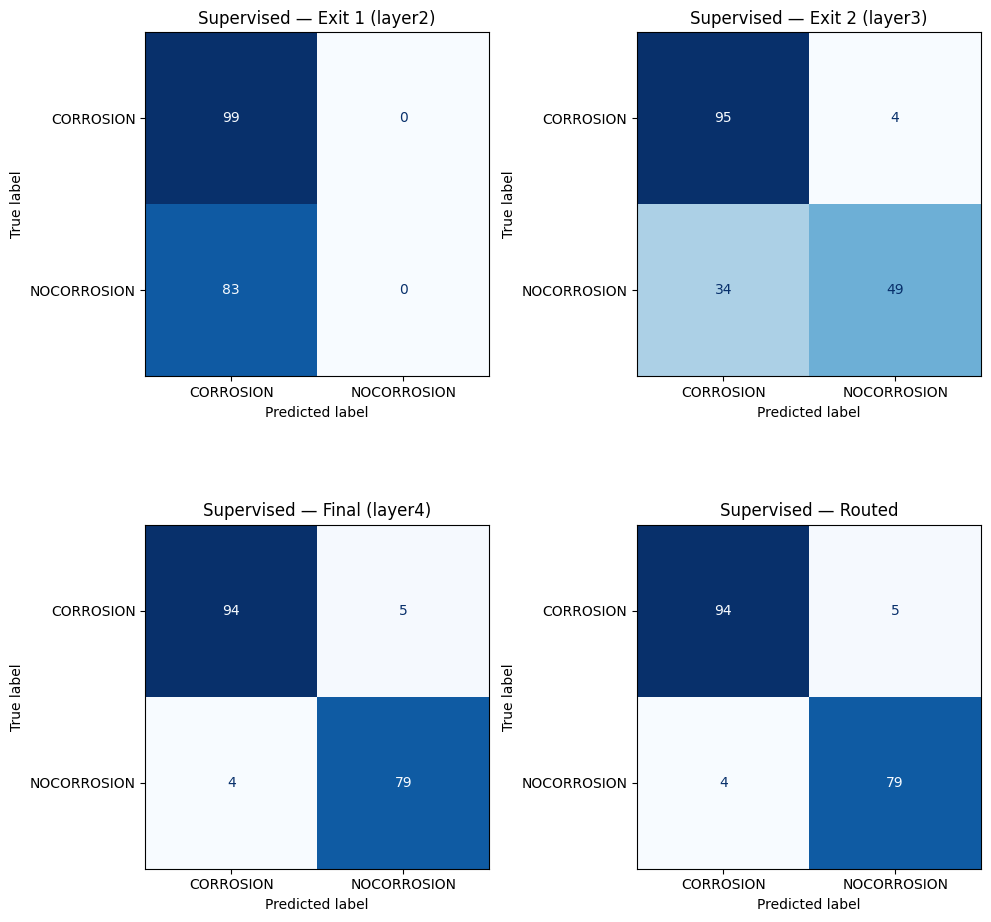

In [21]:
def get_all_exit_predictions(dataloader, tau1=0.90, tau2=0.90):
    backbone.eval(); exit1_head.eval(); exit2_head.eval(); final_head.eval()
    y_true, y_exit1, y_exit2, y_final, y_routed = [], [], [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            e1, e2, ef = forward_early_exit(inputs)
            p1 = torch.softmax(e1, 1); c1, pred1 = p1.max(1)
            p2 = torch.softmax(e2, 1); c2, pred2 = p2.max(1)
            predf = ef.argmax(1)

            routed = []
            for i in range(labels.size(0)):
                if   c1[i] >= tau1: routed.append(pred1[i].item())
                elif c2[i] >= tau2: routed.append(pred2[i].item())
                else:               routed.append(predf[i].item())

            y_true.extend(labels.cpu().numpy())
            y_exit1.extend(pred1.cpu().numpy())
            y_exit2.extend(pred2.cpu().numpy())
            y_final.extend(predf.cpu().numpy())
            y_routed.extend(routed)

    return y_true, y_exit1, y_exit2, y_final, y_routed

y_true, y_exit1, y_exit2, y_final, y_routed = get_all_exit_predictions(test_loader, tau1=0.90, tau2=0.90)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for (title, preds, ax) in [
    ('Exit 1 (layer2)', y_exit1, axes[0,0]),
    ('Exit 2 (layer3)', y_exit2, axes[0,1]),
    ('Final (layer4)',  y_final, axes[1,0]),
    ('Routed',          y_routed, axes[1,1]),
]:
    cm = confusion_matrix(y_true, preds)
    ConfusionMatrixDisplay(cm, display_labels=train_ds.classes).plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f'Supervised — {title}')
plt.tight_layout(); plt.savefig('sup_ee_confusion.png', dpi=150); plt.show()

### Exit Rates and Accuracy vs Threshold

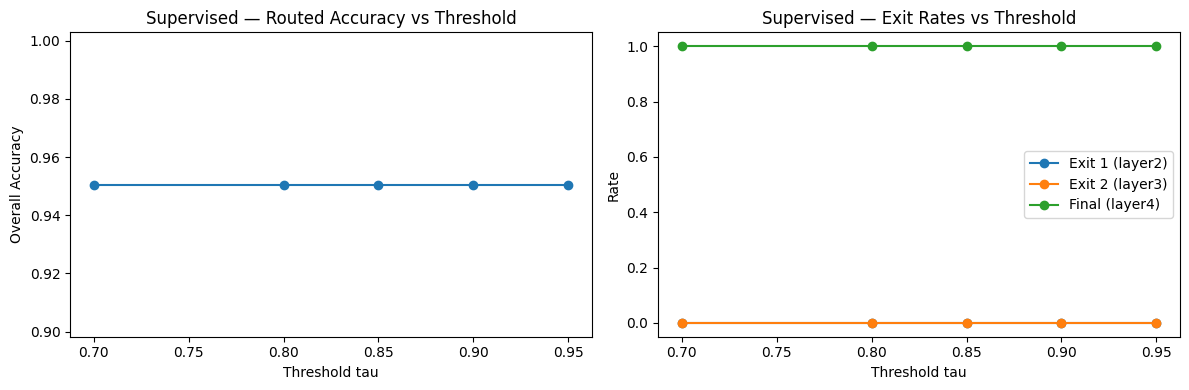

Results saved to sup_ee_results.json


In [22]:
taus        = [x[0] for x in sup_results]
accs        = [x[1] for x in sup_results]
exit1_rates = [x[2] for x in sup_results]
exit2_rates = [x[3] for x in sup_results]
final_rates = [x[4] for x in sup_results]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(taus, accs, marker='o'); plt.xlabel('Threshold tau'); plt.ylabel('Overall Accuracy')
plt.title('Supervised — Routed Accuracy vs Threshold')

plt.subplot(1, 2, 2)
plt.plot(taus, exit1_rates, marker='o', label='Exit 1 (layer2)')
plt.plot(taus, exit2_rates, marker='o', label='Exit 2 (layer3)')
plt.plot(taus, final_rates, marker='o', label='Final (layer4)')
plt.xlabel('Threshold tau'); plt.ylabel('Rate'); plt.legend()
plt.title('Supervised — Exit Rates vs Threshold')
plt.tight_layout(); plt.savefig('sup_ee_rates.png', dpi=150); plt.show()

import json
with open('sup_ee_results.json', 'w') as f:
    json.dump(sup_results, f)
print('Results saved to sup_ee_results.json')

In [1]:
def get_size(model):
    """
    Returns the size of the model in MB.
    """

    torch.save(model.state_dict(), "temp.p")
    size = os.path.getsize("temp.p") / 1e6
    os.remove("temp.p")
    return size

def compress_layer(layer, epsilon=0.10):
    """
    Compresses a layer using SVD if the compression is beneficial.
    Args:
        layer (nn.Module): The layer to compress.
        epsilon (float): The energy threshold for compression.
    Returns:
        nn.Module: The compressed layer or the original layer if compression is not beneficial.
    """

    # handle Linear layers
    if isinstance(layer, nn.Linear):
        # get linear layer weight matrix
        W = layer.weight.data.cpu()
        
        # run SVD on flat weight matrix
        U, S, Vh = torch.linalg.svd(W, full_matrices=False)

        # find rank that capture the asked energy (1-epsilon)
        energy = torch.cumsum(S**2, dim=0) / torch.sum(S**2)
        rank = torch.searchsorted(energy, 1 - epsilon).item() + 1

        # check that factorization actually reduces number of parameters
        old_size = W.numel()
        new_size = rank * (W.shape[0] + W.shape[1])
        if new_size < old_size:
            # define low rank factorization from SVD and rank
            U_r = U[:, :rank] @ torch.diag(S[:rank])
            V_r = Vh[:rank, :]

            # define two linear layers to replace the original linear layer
            compressed_layer = nn.Sequential(
                nn.Linear(W.shape[1], rank, bias=False),
                nn.Linear(rank, W.shape[0], bias=True)
            )
            compressed_layer[0].weight.data = V_r.to(DEVICE)
            compressed_layer[1].weight.data = U_r.to(DEVICE)
            compressed_layer[1].bias.data = layer.bias.data.to(DEVICE)
            return compressed_layer, old_size, new_size
        
    # handle Conv2d layers
    elif isinstance(layer, nn.Conv2d):
        # get convolution weight 4d matrix, shape: [out_channels, in_channels, kH, kW]
        W = layer.weight.data.cpu()  
        OC, IC, kH, kW = W.shape

        # reshape to 2d matrix, with shape: [OC, IC*kH*kW]
        W_flat = W.view(OC, -1)

        # run SVD on flat weight matrix        
        U, S, Vh = torch.linalg.svd(W_flat, full_matrices=False)

        # find rank that capture the asked energy (1-epsilon)
        energy = torch.cumsum(S**2, dim=0) / torch.sum(S**2)
        rank = torch.searchsorted(energy, 1 - epsilon).item() + 1

        # check that factorization actually reduces number of parameters
        old_size = W.numel()
        new_size = rank * (IC * kH * kW + OC)
        if new_size < old_size:
            # define low rank factorization from SVD and rank
            U_r = U[:, :rank] @ torch.diag(S[:rank])
            V_r = Vh[:rank, :]

            # define two convolutional layers to replace the original convolutional layer
            conv1 = nn.Conv2d(
                in_channels=IC,
                out_channels=rank,
                kernel_size=1,
                stride=1,
                padding=0,
                bias=False
            )
            conv2 = nn.Conv2d(
                in_channels=rank,
                out_channels=OC,
                kernel_size=(kH, kW),
                stride=layer.stride,
                padding=layer.padding,
                bias=(layer.bias is not None)
            )
            conv1.weight.data = V_r.view(rank, IC, kH, kW).to(DEVICE)
            conv2.weight.data = U_r.view(OC, rank, 1, 1).to(DEVICE)
            if layer.bias is not None:
                conv2.bias.data = layer.bias.data.to(DEVICE)
            return nn.Sequential(conv1, conv2), old_size, new_size

    return layer, 0, 0  # return the original layer if compression is not beneficial


def compress_model(model, epsilon=0.50):
    """
    Compresses the given model by applying SVD-based compression to Linear and Conv2d layers.
    
    Args:
        model (nn.Module): The model to compress.
        epsilon (float): The energy threshold for compression.
    
    Returns:
        nn.Module: The compressed model.
    """
   
    compressed_model = deepcopy(model)  # Create a copy of the input model

    total_old_size = 0
    total_new_size = 0

    for name, module in compressed_model.named_modules():
        if isinstance(module, (nn.Linear, nn.Conv2d)):
            if '.' in name:  # Check if the module has a parent
                parent, attr = name.rsplit('.', 1)
                parent_module = compressed_model
                for part in parent.split('.'):
                    parent_module = getattr(parent_module, part)
            else:  # Handle top-level modules
                parent_module = compressed_model
                attr = name
            new_layer, old_size, new_size = compress_layer(module, epsilon)
            total_old_size += old_size
            total_new_size += new_size
            setattr(parent_module, attr, new_layer)
    
    return compressed_model, total_old_size, total_new_size

In [61]:
# Evaluate and print metrics for the original model
orig_model = model

orig_acc, r1, r2, rf, routed_preds, routed_labels = evaluate_routed_inference(orig_model, test_loader, tau1=0.90, tau2=0.90)
example_input = torch.rand(128, 3, 32, 32).to(DEVICE)
orig_latency_mu, orig_latency_std = 0, 0#estimate_latency(original_model, example_input)
size_orig = get_size(orig_model)
print(f"Original -> acc: {100*orig_acc:.2f}%, latency: {orig_latency_mu:.2f} ± {orig_latency_std:.2f} ms, size: {size_orig:.2f}MB")

# Iterate over epsilon values
for epsilon in [round(x * 0.1, 2) for x in range(1, 10)]:
    print(f"\nCompressing model with epsilon = {epsilon}...")
    
    # Compress the model
    comp_model, total_old_size, total_new_size = compress_model(orig_model, epsilon=epsilon)
    
    # Evaluate compressed model before fine-tuning
    comp_acc, r1, r2, rf, routed_preds, routed_labels = evaluate_routed_inference(comp_model, test_loader, tau1=0.90, tau2=0.90)
    print(f"Old size: {total_old_size}, New size: {total_new_size}, Parameter count reduction: {total_old_size-total_new_size}")
    print(f"Compressed -> acc before tuning: {100*comp_acc:.2f}%")
    
    # Fine-tune the compressed model
    history = train_model(model=comp_model, criterion=criterion, optimizer=optimizer, train_loader=train_loader, val_loader=val_loader, num_epochs=2, best_path='early_exit_supervised.pt')
    
    # Evaluate compressed model after fine-tuning
    comp_ft_acc, r1, r2, rf, routed_preds, routed_labels = evaluate_routed_inference(comp_model, test_loader, tau1=0.90, tau2=0.90)
    comp_latency_mu, comp_latency_std = 0,0#estimate_latency(compressed_model, example_input)
    size_comp = get_size(comp_model)
    
    # Print metrics for the fine-tuned compressed model
    print(f"Compressed -> acc after tuning: {100*comp_ft_acc:.2f}%, latency: {comp_latency_mu:.2f} ± {comp_latency_std:.2f} ms, size: {size_comp:.2f}MB")

Accuracy: 0.9066 | Exit1: 0.0110 | Exit2: 0.5000 | Final: 0.4890
Original -> acc: 90.66%, latency: 0.00 ± 0.00 ms, size: 45.19MB

Compressing model with epsilon = 0.1...
Accuracy: 0.8187 | Exit1: 0.0000 | Exit2: 0.0934 | Final: 0.9066
Old size: 11166912, New size: 7775337, Parameter count reduction: 3391575
Compressed -> acc before tuning: 81.87%
Epoch 1/2
----------
train | loss=0.5328 | exit1=0.7863 | exit2=0.8450 | final=0.8727
val   | loss=0.7997 | exit1=0.7351 | exit2=0.8162 | final=0.8040

Epoch 2/2
----------
train | loss=0.5022 | exit1=0.7962 | exit2=0.8545 | final=0.8775
val   | loss=0.7395 | exit1=0.7397 | exit2=0.8101 | final=0.8162

Best val final acc: 0.8162327718223583
Accuracy: 0.8462 | Exit1: 0.0000 | Exit2: 0.3681 | Final: 0.6319
Compressed -> acc after tuning: 84.62%, latency: 0.00 ± 0.00 ms, size: 48.43MB

Compressing model with epsilon = 0.2...
Accuracy: 0.6099 | Exit1: 0.0000 | Exit2: 0.0934 | Final: 0.9066
Old size: 11167424, New size: 5730188, Parameter count red

---
# Section 3 — Comparison: SimCLR vs Supervised

# Early Exit Comparison: SimCLR vs Supervised
Loads saved results from both early exit notebooks and compares accuracy, exit rates, and efficiency across thresholds.

**Run `early_exit_simclr.ipynb` and `early_exit_supervised.ipynb` first** to generate the `.json` and `.pt` result files.

In [23]:
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from pathlib import Path
import torch.nn.functional as F

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', DEVICE)

with open('simclr_ee_results.json') as f:
    simclr_results = json.load(f)
with open('sup_ee_results.json') as f:
    sup_results = json.load(f)

print('SimCLR results loaded:', len(simclr_results), 'thresholds')
print('Supervised results loaded:', len(sup_results), 'thresholds')

Device: mps
SimCLR results loaded: 5 thresholds
Supervised results loaded: 5 thresholds


### Accuracy vs Threshold

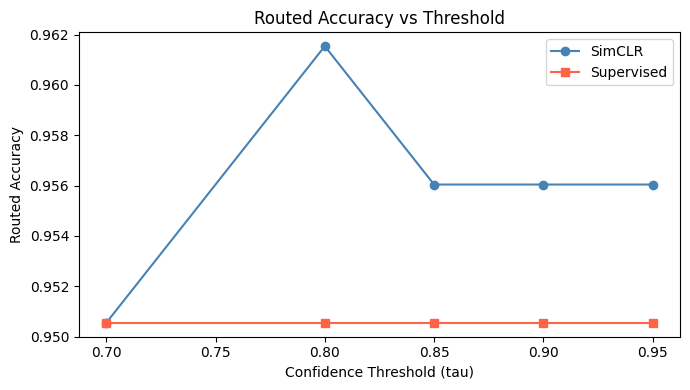

In [24]:
taus        = [x[0] for x in simclr_results]
simclr_accs = [x[1] for x in simclr_results]
sup_accs    = [x[1] for x in sup_results]

plt.figure(figsize=(7, 4))
plt.plot(taus, simclr_accs, 'o-', label='SimCLR', color='steelblue')
plt.plot(taus, sup_accs,    's-', label='Supervised', color='tomato')
plt.xlabel('Confidence Threshold (tau)')
plt.ylabel('Routed Accuracy')
plt.title('Routed Accuracy vs Threshold')
plt.legend(); plt.tight_layout()
plt.savefig('compare_accuracy.png', dpi=150); plt.show()

### Early Exit Rate vs Threshold

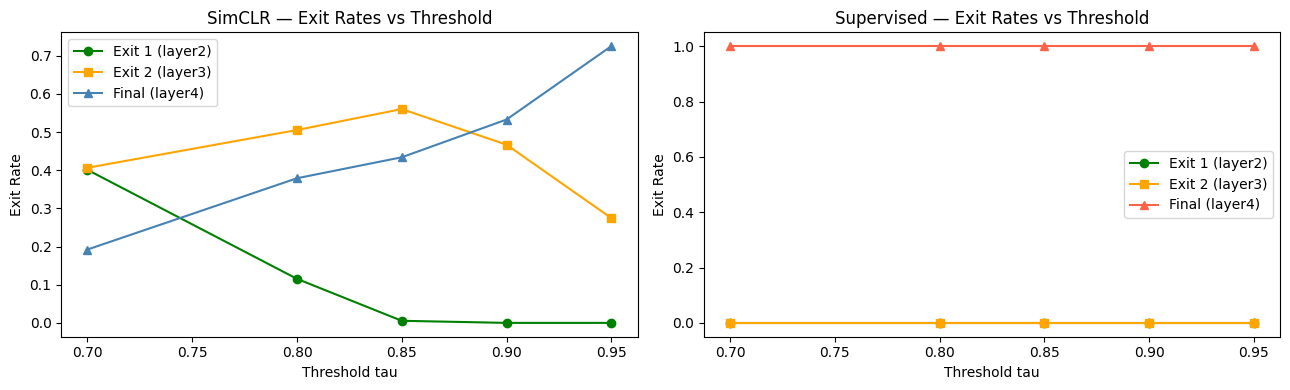

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, results, name, color in [
    (axes[0], simclr_results, 'SimCLR',     'steelblue'),
    (axes[1], sup_results,    'Supervised', 'tomato'),
]:
    taus = [x[0] for x in results]
    ax.plot(taus, [x[2] for x in results], 'o-', label='Exit 1 (layer2)', color='green')
    ax.plot(taus, [x[3] for x in results], 's-', label='Exit 2 (layer3)', color='orange')
    ax.plot(taus, [x[4] for x in results], '^-', label='Final (layer4)',  color=color)
    ax.set_xlabel('Threshold tau'); ax.set_ylabel('Exit Rate')
    ax.set_title(f'{name} — Exit Rates vs Threshold')
    ax.legend()

plt.tight_layout(); plt.savefig('compare_exit_rates.png', dpi=150); plt.show()

### Summary Table (tau=0.90)

In [26]:
import pandas as pd

rows = []
for results, name in [(simclr_results, 'SimCLR'), (sup_results, 'Supervised')]:
    # Find tau=0.90
    r = next(x for x in results if abs(x[0] - 0.90) < 0.001)
    rows.append({
        'Model':         name,
        'Accuracy':      f'{r[1]:.4f}',
        'Exit1 Rate':    f'{r[2]:.4f}',
        'Exit2 Rate':    f'{r[3]:.4f}',
        'Final Rate':    f'{r[4]:.4f}',
        'Early Exit %':  f'{(r[2]+r[3])*100:.1f}%',
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

     Model Accuracy Exit1 Rate Exit2 Rate Final Rate Early Exit %
    SimCLR   0.9560     0.0000     0.4670     0.5330        46.7%
Supervised   0.9505     0.0000     0.0000     1.0000         0.0%


### Accuracy vs Early Exit Rate (efficiency frontier)

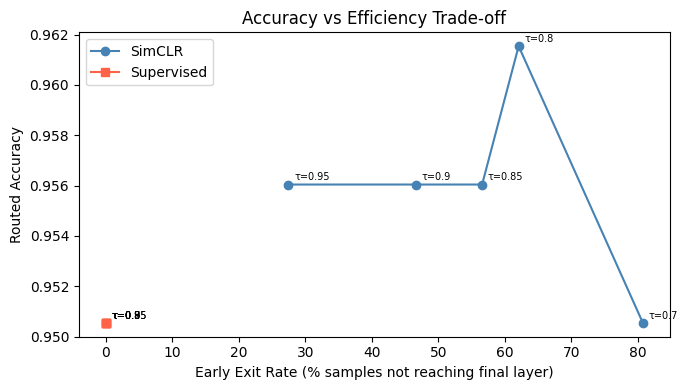

In [27]:
plt.figure(figsize=(7, 4))

for results, name, color, marker in [
    (simclr_results, 'SimCLR',     'steelblue', 'o'),
    (sup_results,    'Supervised', 'tomato',    's'),
]:
    early_pcts = [(x[2]+x[3])*100 for x in results]
    accs       = [x[1] for x in results]
    taus_lbl   = [x[0] for x in results]
    plt.plot(early_pcts, accs, marker+'-', color=color, label=name)
    for ep, ac, tau in zip(early_pcts, accs, taus_lbl):
        plt.annotate(f'τ={tau}', (ep, ac), textcoords='offset points', xytext=(4, 3), fontsize=7)

plt.xlabel('Early Exit Rate (% samples not reaching final layer)')
plt.ylabel('Routed Accuracy')
plt.title('Accuracy vs Efficiency Trade-off')
plt.legend(); plt.tight_layout()
plt.savefig('compare_frontier.png', dpi=150); plt.show()

### run side by sied on test set

In [28]:
test_dir = Path('dataset_ood/test')
val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
test_ds     = ImageFolder(test_dir, transform=val_tfms)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)
num_classes = len(test_ds.classes)
print('Classes:', test_ds.classes)

Classes: ['CORROSION', 'NOCORROSION']


In [29]:
def build_backbone_and_heads(num_classes, device):
    backbone   = models.resnet18(weights=None)
    backbone.fc = nn.Identity()
    backbone    = backbone.to(device)
    exit1_head = nn.Sequential(nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(), nn.Linear(128, num_classes)).to(device)
    exit2_head = nn.Sequential(nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(), nn.Linear(256, num_classes)).to(device)
    final_head = nn.Linear(512, num_classes).to(device)
    return backbone, exit1_head, exit2_head, final_head

def load_ee_checkpoint(path, num_classes, device):
    bb, e1, e2, ef = build_backbone_and_heads(num_classes, device)
    ckpt = torch.load(path, map_location=device)
    bb.load_state_dict(ckpt['backbone'])
    e1.load_state_dict(ckpt['exit1_head'])
    e2.load_state_dict(ckpt['exit2_head'])
    ef.load_state_dict(ckpt['final_head'])
    for m in [bb, e1, e2, ef]: m.eval()
    return bb, e1, e2, ef

def make_forward(bb):
    def forward_early_exit(x):
        x = bb.conv1(x); x = bb.bn1(x); x = bb.relu(x); x = bb.maxpool(x)
        x = bb.layer1(x); x = bb.layer2(x); e1 = None  # filled below
        return x
    return forward_early_exit

def evaluate_model(backbone, exit1_head, exit2_head, final_head, dataloader, tau1=0.90, tau2=0.90):
    for m in [backbone, exit1_head, exit2_head, final_head]: m.eval()
    total = correct = c1 = c2 = cf = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            x = backbone.conv1(inputs); x = backbone.bn1(x); x = backbone.relu(x); x = backbone.maxpool(x)
            x = backbone.layer1(x)
            x = backbone.layer2(x); e1_logits = exit1_head(x)
            x = backbone.layer3(x); e2_logits = exit2_head(x)
            x = backbone.layer4(x); x = backbone.avgpool(x); x = torch.flatten(x, 1)
            ef_logits = final_head(x)

            p1 = torch.softmax(e1_logits, 1); conf1, pred1 = p1.max(1)
            p2 = torch.softmax(e2_logits, 1); conf2, pred2 = p2.max(1)
            predf = ef_logits.argmax(1)

            batch_preds = []
            for i in range(labels.size(0)):
                if   conf1[i] >= tau1: batch_preds.append(pred1[i].item()); c1 += 1
                elif conf2[i] >= tau2: batch_preds.append(pred2[i].item()); c2 += 1
                else:                  batch_preds.append(predf[i].item()); cf += 1

            bt = torch.tensor(batch_preds, device=labels.device)
            correct += (bt == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(batch_preds)
            all_labels.extend(labels.cpu().numpy())

    return correct/total, c1/total, c2/total, cf/total, all_preds, all_labels

# Load both models
bb_s, e1_s, e2_s, ef_s = load_ee_checkpoint('early_exit_simclr.pt',     num_classes, DEVICE)
bb_p, e1_p, e2_p, ef_p = load_ee_checkpoint('early_exit_supervised.pt', num_classes, DEVICE)
print('Both models loaded.')

Both models loaded.


In [30]:
TAU = 0.90
acc_s, r1_s, r2_s, rf_s, preds_s, labels_s = evaluate_model(bb_s, e1_s, e2_s, ef_s, test_loader, TAU, TAU)
acc_p, r1_p, r2_p, rf_p, preds_p, labels_p = evaluate_model(bb_p, e1_p, e2_p, ef_p, test_loader, TAU, TAU)

print(f'\nSimCLR     — acc={acc_s:.4f} | exit1={r1_s:.4f} | exit2={r2_s:.4f} | final={rf_s:.4f}')
print(f'Supervised — acc={acc_p:.4f} | exit1={r1_p:.4f} | exit2={r2_p:.4f} | final={rf_p:.4f}')


SimCLR     — acc=0.9560 | exit1=0.0000 | exit2=0.4670 | final=0.5330
Supervised — acc=0.9505 | exit1=0.0000 | exit2=0.0000 | final=1.0000


### Confusion matrices (tau=0.90)

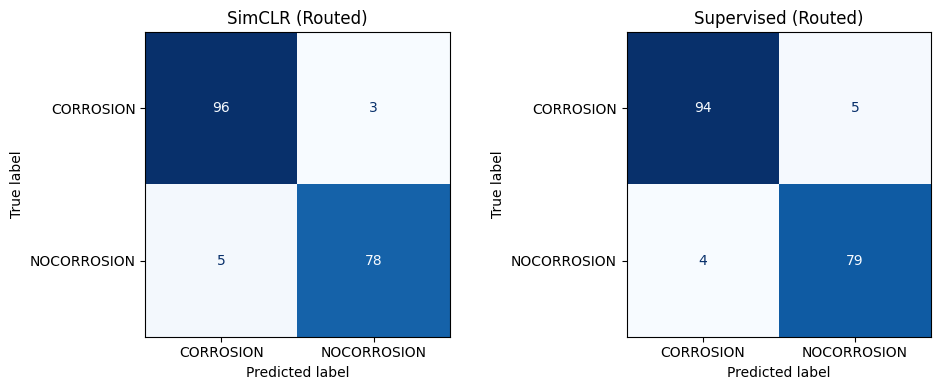

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, labels, name in [
    (axes[0], preds_s, labels_s, 'SimCLR (Routed)'),
    (axes[1], preds_p, labels_p, 'Supervised (Routed)'),
]:
    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(cm, display_labels=test_ds.classes).plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.savefig('compare_confusion.png', dpi=150); plt.show()

	                                SimCLR	Supervised
Test accuracy (routed)	       |    95.6%	95.1%

Early exit rate (tau=0.90)	   |    46.7%	0%

Val final acc	               |    89.3%	91.1%

Best for deployment efficiency |	  YES	No

Best raw accuracy	           |       No	Marginal

SimCLR better for deplyment: skip easier samples while keeping decent accuracy